# Parameter Sensitivity Sweep

Sweep each `DevelopmentalParams` field. This isolates each parameter's causal effect.

**Design**
- One fixed task across every run (medium distance, 90° rotation demand).
- One baseline parameter set (mid-range, roughly Stage B).
- For each parameter: 7 values.
- 25 trials per condition for stable averages.

**Outputs tracked**
| Metric | Captures |
|---|---|
| success_rate | Whether the agent solves the task |
| mean_efficiency | Directness of the movement path (1 = straight line) |
| mean_movement_onset | Timesteps of deliberation before first move |
| mean_gaze_switches | Fixation switches between object and target |
| mean_pos_error | Final position error at trial end |
| mean_angle_error | Final angle error at trial end |
| mean_target_fixation_pct | Fraction of time fixating the goal |

A vertical dashed line on each plot marks the baseline parameter value.

The final section produces an animated trial comparison for the 6 most influential
parameters, showing Low / Baseline / High

In [ ]:
from dataclasses import replace
from pathlib import Path
import sys
import math
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from pathlib import Path
from matplotlib.animation import FFMpegWriter
from dataclasses import replace

cwd = Path.cwd()
# if (cwd / "planning_cascade_model.py").exists():
#     sys.path.insert(0, str(cwd))
# elif (cwd / "gaze_model" / "planning_cascade_model.py").exists():
#     sys.path.insert(0, str(cwd / "gaze_model"))

from model_utils import DevelopmentalParams, TaskConfig
from planning_cascade_model import run_trial

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Task and Baseline

**Task**: a hard task — 0.9 units distance with a large 135° rotation required,
using a wide flat object (aspect ratio 2:1). This simultaneously stresses
deliberation time, orientation control, and path length, making parameter
differences more discriminating than on an easy condition.

**Baseline**: a mid-range parameter set. Sweeping each parameter from this
midpoint reveals effects in both directions.

In [2]:
TASK = TaskConfig(
    name="hard_task",
    start_x=0.0, start_y=0.0, start_angle=0.0,
    goal_x=0.90, goal_y=0.0, goal_angle=math.pi * (3 / 4),  # 135° rotation, far away
    obj_width=0.60, obj_height=0.30,                          # wide flat object (2:1 ratio)
    max_timesteps=180,
)

BASELINE = DevelopmentalParams(
    name="sweep_baseline",
    gaze_switch_rate=0.35,
    fixation_duration_mean=3.5,
    target_bias=0.40,
    simultaneous_rate=0.20,
    sampling_rate=0.55,
    perceptual_noise=0.20,
    location_acuity=0.85,
    orientation_acuity=0.45,
    relation_acuity=0.20,
    wm_capacity=3,
    wm_decay=0.10,
    wm_unfixated_decay=0.25,
    affordance_coupling=0.50,
    affordance_noise=0.18,
    planning_horizon=3,
    motor_noise=0.18,
    habit_strength=0.50,
    goal_directed_strength=0.50,
    correction_rate=0.18,
    correction_delay=1,
    initiation_threshold=0.28,
)

N_TRIALS = 25
SEED     = 42

print(f"Task: {TASK.name}  |  goal=({TASK.goal_x}, {TASK.goal_y}, {np.degrees(TASK.goal_angle):.0f}°)")
print(f"Object: {TASK.obj_width:.2f} × {TASK.obj_height:.2f}  (aspect {TASK.obj_width/TASK.obj_height:.1f}:1)  |  max_t={TASK.max_timesteps}")
print(f"Baseline params: {BASELINE}")

Task: hard_task  |  goal=(0.9, 0.0, 135°)
Object: 0.60 × 0.30  (aspect 2.0:1)  |  max_t=180
Baseline params: DevelopmentalParams(name='sweep_baseline', gaze_switch_rate=0.35, fixation_duration_mean=3.5, target_bias=0.4, simultaneous_rate=0.2, sampling_rate=0.55, perceptual_noise=0.2, location_acuity=0.85, orientation_acuity=0.45, relation_acuity=0.2, wm_capacity=3, wm_decay=0.1, wm_unfixated_decay=0.25, affordance_coupling=0.5, affordance_noise=0.18, planning_horizon=3, motor_noise=0.18, habit_strength=0.5, goal_directed_strength=0.5, correction_rate=0.18, correction_delay=1, initiation_threshold=0.28, affordance_matrix_variant='baseline')


## Sweep Configuration

Each parameter is given 7 test values spanning its meaningful range.

**One parameter at a time.**  Every sweep condition holds all other parameters
fixed at `BASELINE` so only the parameter currently under study deviates.
This ensures that any change in model output is attributable solely to that
one parameter.

`habit_strength`: `goal_directed_strength` is set to `1 − habit_strength`
throughout the sweep so the two always sum to 1.  Sweeping them independently would conflate their individual effects.

In [3]:
def linvals(lo, hi, n=7):
    return [round(v, 4) for v in np.linspace(lo, hi, n).tolist()]

SWEEP_CONFIG = {
    # Gaze
    "gaze_switch_rate":       linvals(0.05, 0.70),
    "fixation_duration_mean": [1.0, 2.0, 3.0, 4.5, 6.0, 8.0, 10.0],
    "target_bias":            linvals(0.05, 0.80),
    "simultaneous_rate":      linvals(0.01, 0.60),
    # Perception 
    "sampling_rate":          linvals(0.10, 0.95),
    "perceptual_noise":       linvals(0.01, 0.50),
    "location_acuity":        linvals(0.30, 1.00),
    "orientation_acuity":     linvals(0.05, 1.00),
    "relation_acuity":        linvals(0.01, 0.80),
    # Working Memory 
    "wm_capacity":            [1, 2, 3, 4, 5, 6, 7],
    "wm_decay":               linvals(0.02, 0.30),
    "wm_unfixated_decay":     linvals(0.05, 0.55),
    # Affordance 
    "affordance_coupling":    linvals(0.10, 1.00),
    "affordance_noise":       linvals(0.01, 0.45),
    # Motor & Control
    "planning_horizon":       [1, 2, 3, 4, 5, 6],
    "motor_noise":            linvals(0.01, 0.45),
    "habit_strength":         linvals(0.05, 0.95),   # goal_directed_strength = 1 − habit_strength
    "correction_rate":        linvals(0.02, 0.40),
    "correction_delay":       [0, 1, 2, 3, 4, 5],
    "initiation_threshold":   linvals(0.05, 0.60),
}

# Group parameters by model component for plotting
PARAM_GROUPS = {
    "Gaze":           ["gaze_switch_rate", "fixation_duration_mean", "target_bias", "simultaneous_rate"],
    "Perception":     ["sampling_rate", "perceptual_noise", "location_acuity", "orientation_acuity", "relation_acuity"],
    "Working Memory": ["wm_capacity", "wm_decay", "wm_unfixated_decay"],
    "Affordance":     ["affordance_coupling", "affordance_noise"],
    "Motor & Control":["planning_horizon", "motor_noise", "habit_strength", "correction_rate",
                       "correction_delay", "initiation_threshold"],
}

total_runs = sum(len(v) for v in SWEEP_CONFIG.values()) * N_TRIALS
print(f"{len(SWEEP_CONFIG)} parameters × avg {total_runs // (len(SWEEP_CONFIG) * N_TRIALS)} values × {N_TRIALS} trials = {total_runs} total runs")

20 parameters × avg 6 values × 25 trials = 3450 total runs


## Run Sweeps

Each parameter is varied across its range while all others remain at `BASELINE`.
Results are stored in `sweep_data[param_name][value]` as a dict of aggregated metrics.

In [4]:
def aggregate(trial_results):
    """Compute mean metrics from a list of TrialResult objects."""
    return {
        "success_rate":          float(np.mean([r.success for r in trial_results])),
        "mean_pos_error":        float(np.mean([r.final_pos_error for r in trial_results])),
        "mean_angle_error":      float(np.mean([r.final_angle_error for r in trial_results])),
        "mean_efficiency":       float(np.mean([r.efficiency for r in trial_results])),
        "mean_timesteps":        float(np.mean([r.timesteps_used for r in trial_results])),
        "mean_movement_onset":   float(np.mean([r.movement_onset for r in trial_results])),
        "mean_gaze_switches":    float(np.mean([r.total_gaze_switches for r in trial_results])),
        "mean_target_fixation":  float(np.mean([r.target_fixation_pct for r in trial_results])),
        "mean_object_fixation":  float(np.mean([r.object_fixation_pct for r in trial_results])),
        "translate_before_rotate": float(np.mean([
            r.translation_onset < r.rotation_onset for r in trial_results
        ])),
    }


sweep_data = {}   # sweep_data[param][value] = metrics dict

t0 = time.time()
for param_name, values in SWEEP_CONFIG.items():
    sweep_data[param_name] = {}
    for val in values:
        overrides = {param_name: val}
        # habit and goal-directed always sum to 1
        if param_name == "habit_strength":
            overrides["goal_directed_strength"] = round(1.0 - val, 4)
        params = replace(BASELINE, **overrides)
        trials = [run_trial(params, TASK, seed=SEED + i, trial_id=i) for i in range(N_TRIALS)]
        sweep_data[param_name][val] = aggregate(trials)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s — {total_runs} trials across {len(SWEEP_CONFIG)} parameters")

Done in 81.6s — 3450 trials across 20 parameters


## Sensitivity Heatmap

Each cell shows the normalised effect size for one (parameter, metric) pair:
the range of metric values across the sweep, divided by the maximum such range
across all parameters for that metric. A value of 1 means this parameter
causes the largest swing in that metric and 0 means no effect.

Parameters are sorted from most to least influential (by mean effect across metrics).

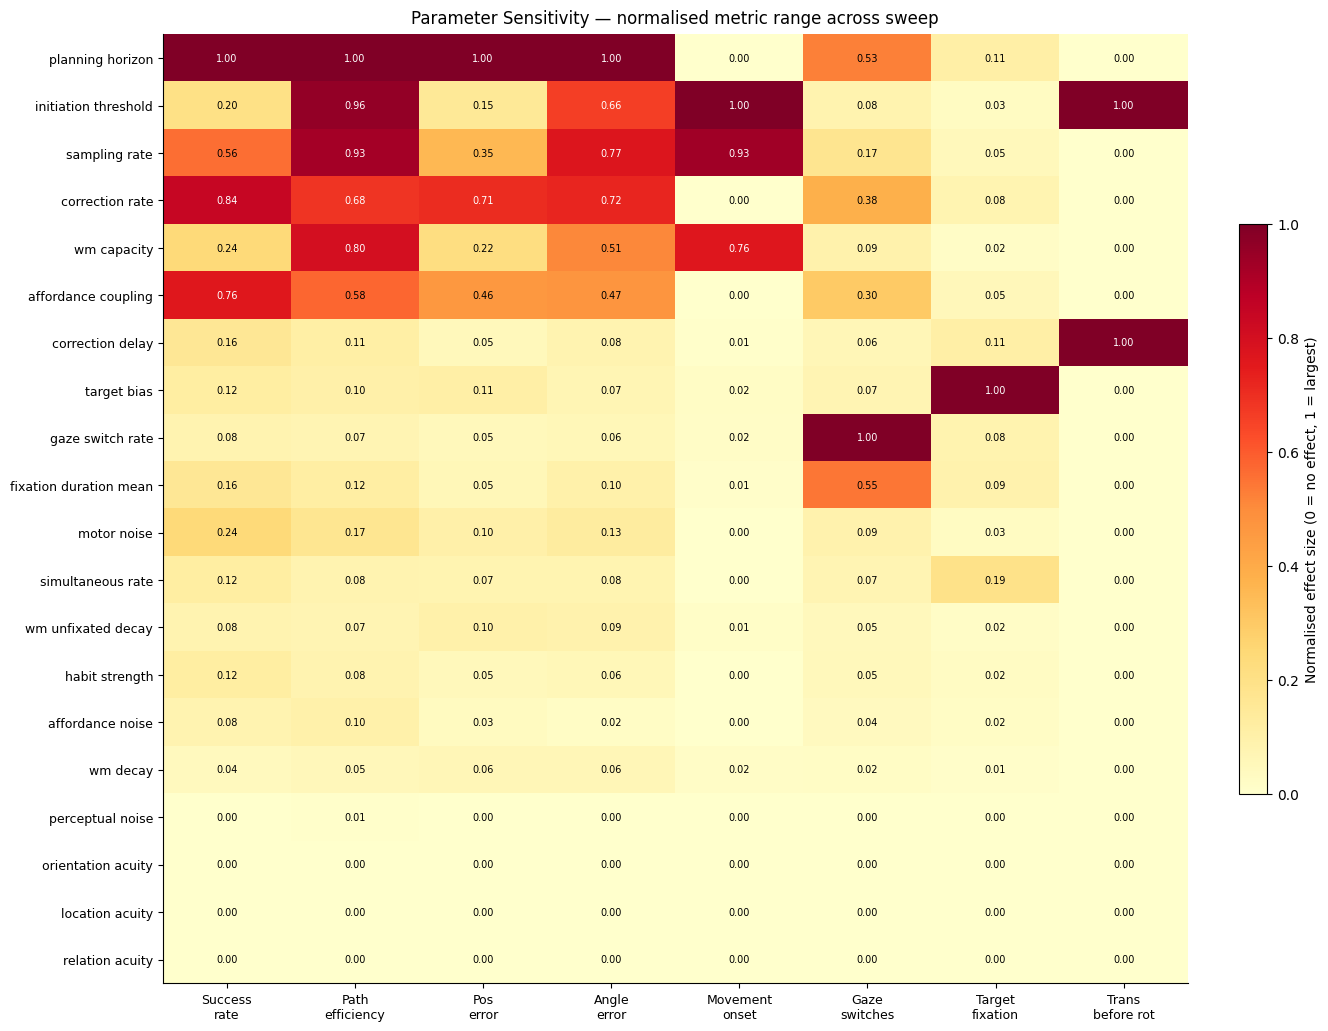

Most influential parameters (by mean normalised effect):
  1. planning_horizon                mean=0.579
  2. initiation_threshold            mean=0.511
  3. sampling_rate                   mean=0.471
  4. correction_rate                 mean=0.426
  5. wm_capacity                     mean=0.330
  6. affordance_coupling             mean=0.327


In [5]:
HEATMAP_METRICS = [
    ("success_rate",         "Success\nrate"),
    ("mean_efficiency",      "Path\nefficiency"),
    ("mean_pos_error",       "Pos\nerror"),
    ("mean_angle_error",     "Angle\nerror"),
    ("mean_movement_onset",  "Movement\nonset"),
    ("mean_gaze_switches",   "Gaze\nswitches"),
    ("mean_target_fixation", "Target\nfixation"),
    ("translate_before_rotate", "Trans\nbefore rot"),
]

all_params = list(SWEEP_CONFIG)

# Compute raw ranges
raw = np.zeros((len(all_params), len(HEATMAP_METRICS)))
for r, param in enumerate(all_params):
    vals = sorted(sweep_data[param])
    for c, (metric, _) in enumerate(HEATMAP_METRICS):
        series = [sweep_data[param][v][metric] for v in vals]
        raw[r, c] = max(series) - min(series)

# Normalise each column by its maximum across parameters
col_max = raw.max(axis=0)
col_max[col_max == 0] = 1.0
normed = raw / col_max

# Sort rows by mean normalised effect
row_order = np.argsort(normed.mean(axis=1))[::-1]
sorted_params  = [all_params[i] for i in row_order]
sorted_normed  = normed[row_order]

fig, ax = plt.subplots(figsize=(len(HEATMAP_METRICS) * 1.4 + 2, len(all_params) * 0.45 + 1.2),
                       constrained_layout=True)
im = ax.imshow(sorted_normed, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(HEATMAP_METRICS)))
ax.set_xticklabels([label for _, label in HEATMAP_METRICS], fontsize=9)
ax.set_yticks(range(len(sorted_params)))
ax.set_yticklabels([p.replace("_", " ") for p in sorted_params], fontsize=9)

# Annotate cells
for r in range(len(sorted_params)):
    for c in range(len(HEATMAP_METRICS)):
        v = sorted_normed[r, c]
        ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="white" if v > 0.65 else "black")

# Group separators
group_boundaries = []
pos = 0
for group_params in PARAM_GROUPS.values():
    pos += len(group_params)
    # find position in sorted order
    for p in group_params:
        idx = sorted_params.index(p) if p in sorted_params else None

fig.colorbar(im, ax=ax, shrink=0.6, label="Normalised effect size (0 = no effect, 1 = largest)")
ax.set_title("Parameter Sensitivity — normalised metric range across sweep", fontsize=12, pad=8)
plt.show()

# Print top 6 most influential parameters
print("Most influential parameters (by mean normalised effect):")
for i, param in enumerate(sorted_params[:6]):
    print(f"  {i+1}. {param:30s}  mean={normed[all_params.index(param)].mean():.3f}")

## Parameter Plots by Model Component

Each row is one parameter. Columns show four key output metrics:

| Column | Interpretation |
|---|---|
| **Success rate** | Does the parameter enable or disable task completion? |
| **Path efficiency** | Does it produce direct or wandering movement? |
| **Movement onset** | Does it lengthen or shorten the pre-movement information phase? |
| **Gaze switches** | Does it increase or reduce attention-switching between object and target? |

The vertical dashed line marks the baseline value.

In [6]:
PLOT_METRICS = [
    ("success_rate",        "Success rate",       "#2196F3", (0, 1.05)),
    ("mean_efficiency",     "Path efficiency",    "#E76C1F", (0, 1.05)),
    ("mean_movement_onset", "Movement onset (ts)","#7C0DC2", None),
    ("mean_gaze_switches",  "Gaze switches",      "#2E7D32", None),
]


def plot_group_sweep(group_name, param_names, colour="#555555"):
    """Plot each parameter in param_names across all PLOT_METRICS."""
    n_rows = len(param_names)
    n_cols = len(PLOT_METRICS)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 2.6 * n_rows),
        constrained_layout=True,
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, param in enumerate(param_names):
        values  = sorted(sweep_data[param])
        b_val   = getattr(BASELINE, param)
        is_last = row == n_rows - 1

        for col, (metric, col_title, line_col, ylim) in enumerate(PLOT_METRICS):
            ax = axes[row, col]
            y  = [sweep_data[param][v][metric] for v in values]

            ax.plot(values, y, "o-", color=line_col, lw=2, markersize=5, zorder=3)
            ax.axvline(b_val, color="#bbbbbb", lw=1.5, ls="--", zorder=2)

            # Baseline dot on the curve (interpolated if b_val not a sweep point)
            b_y = float(np.interp(b_val, values, y))
            ax.scatter([b_val], [b_y], color="black", s=35, zorder=5, clip_on=False)

            if ylim:
                ax.set_ylim(*ylim)
            if row == 0:
                ax.set_title(col_title, fontsize=10, color=line_col)
            if col == 0:
                ax.set_ylabel(param.replace("_", "\n"), fontsize=8,
                              rotation=0, ha="right", va="center", labelpad=4)
            if is_last:
                ax.set_xlabel("parameter value", fontsize=7)

            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.25)
            ax.xaxis.set_major_locator(mticker.MaxNLocator(5))

    fig.suptitle(f"{group_name} - effect of each parameter in isolation",
                 fontsize=13, fontweight="bold")
    plt.show()

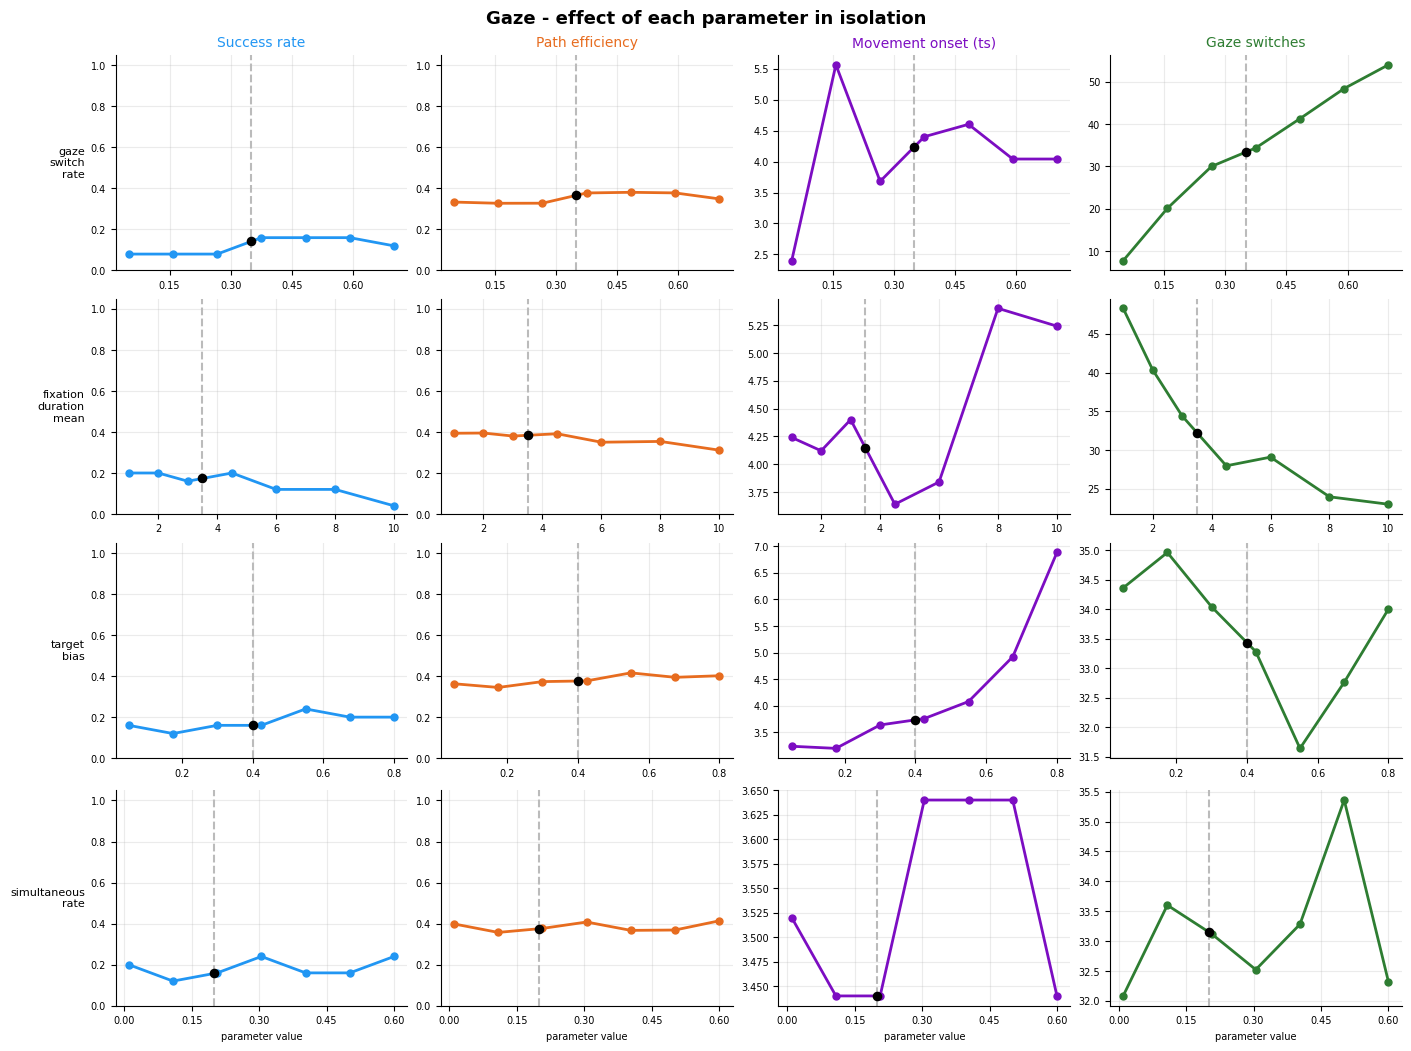

In [7]:
plot_group_sweep("Gaze", PARAM_GROUPS["Gaze"])

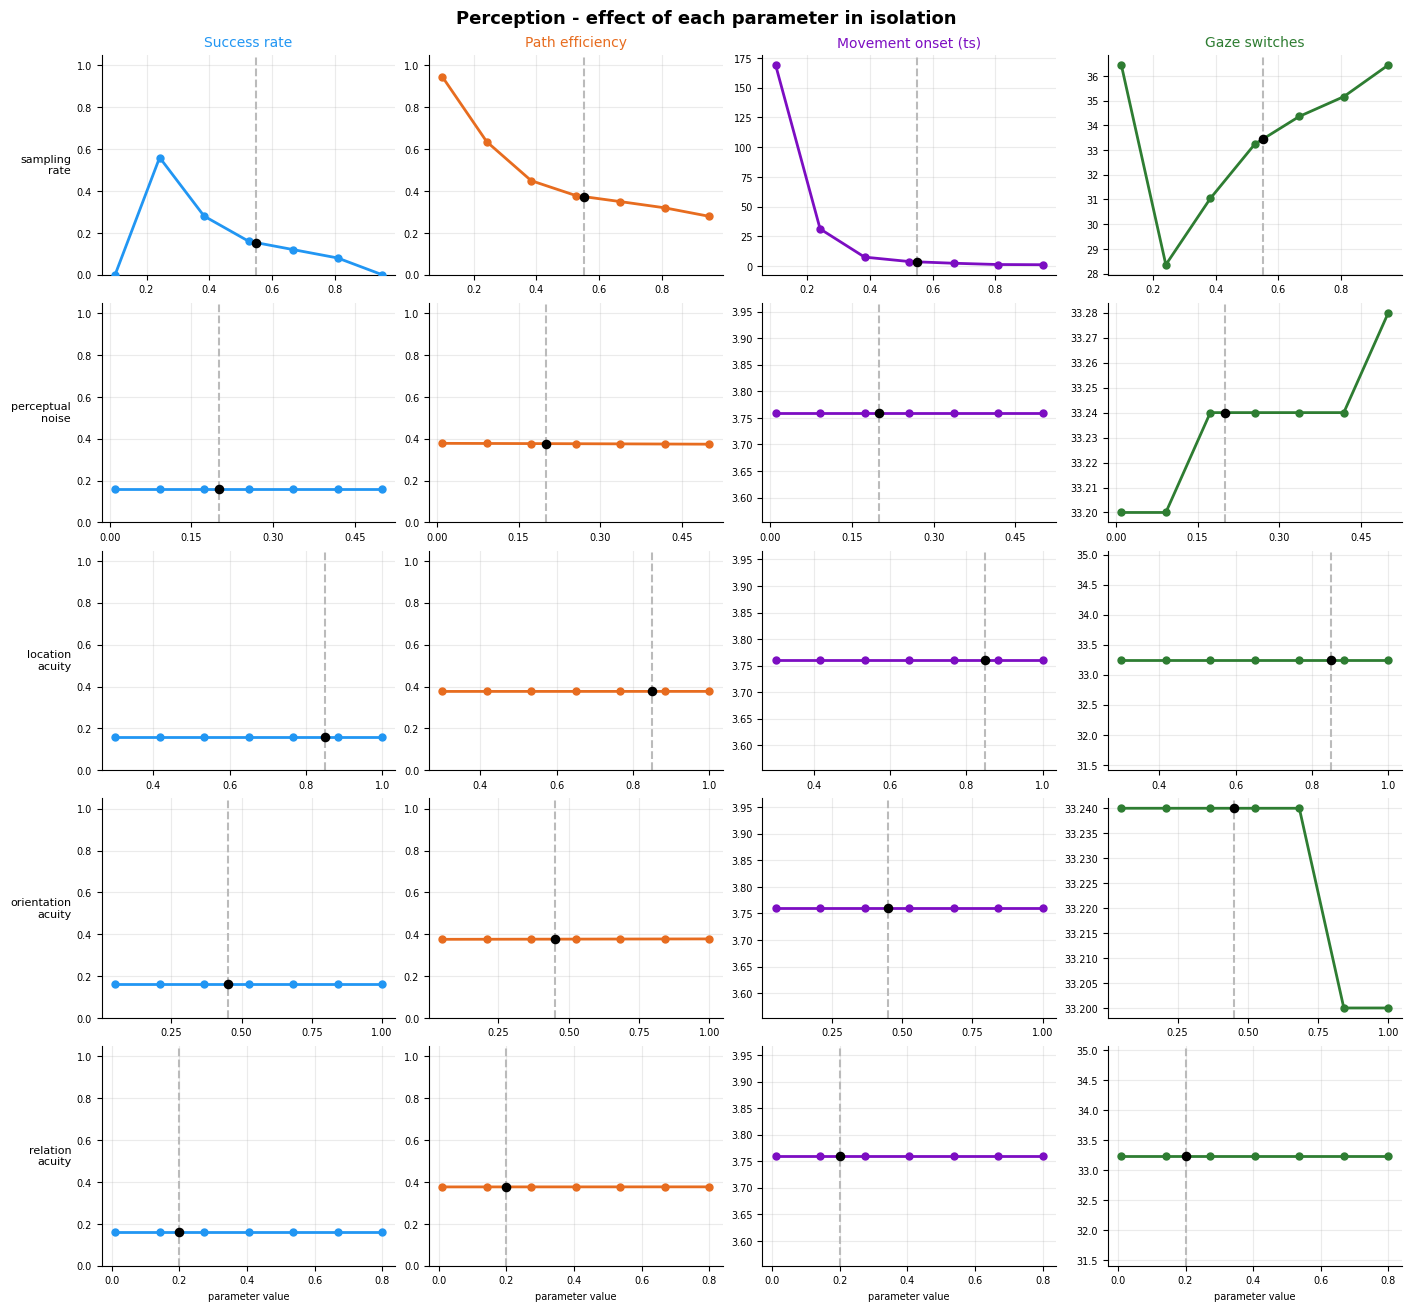

In [8]:
plot_group_sweep("Perception", PARAM_GROUPS["Perception"])

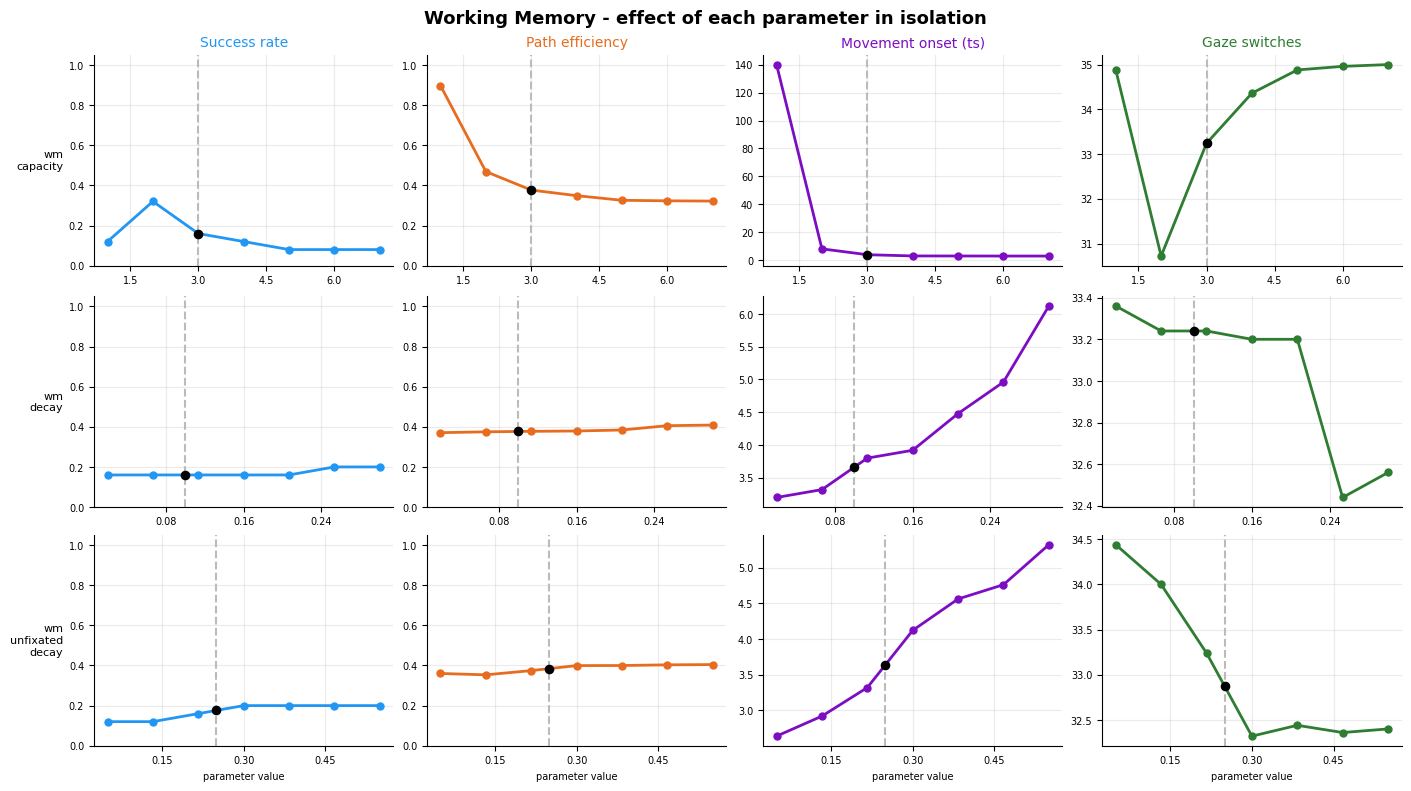

In [9]:
plot_group_sweep("Working Memory", PARAM_GROUPS["Working Memory"])

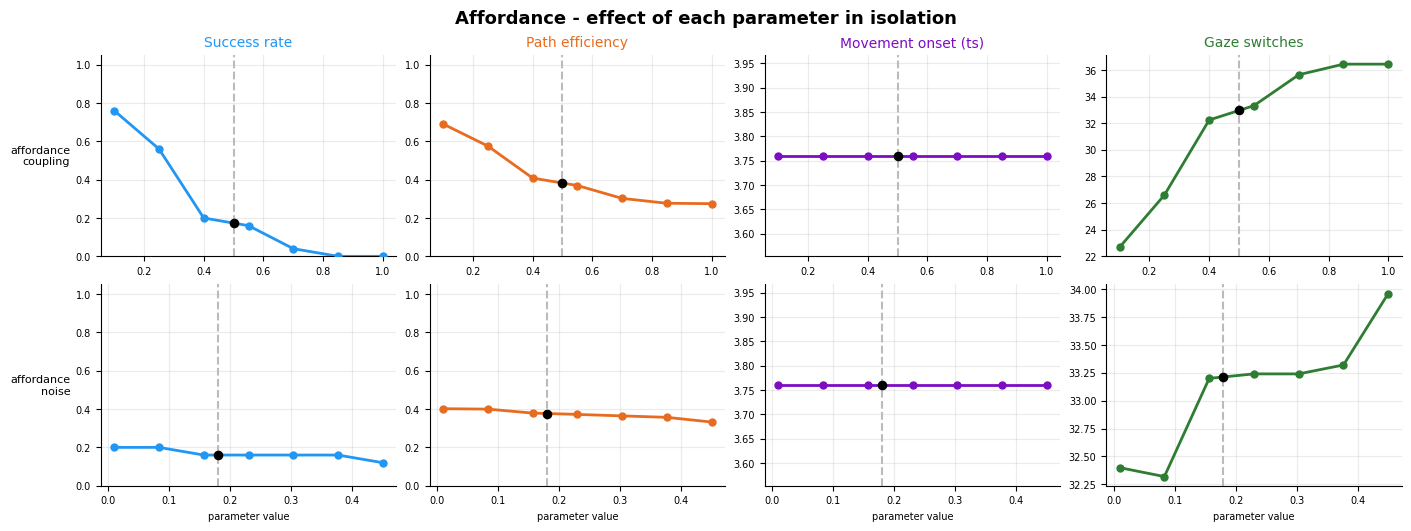

In [10]:
plot_group_sweep("Affordance", PARAM_GROUPS["Affordance"])

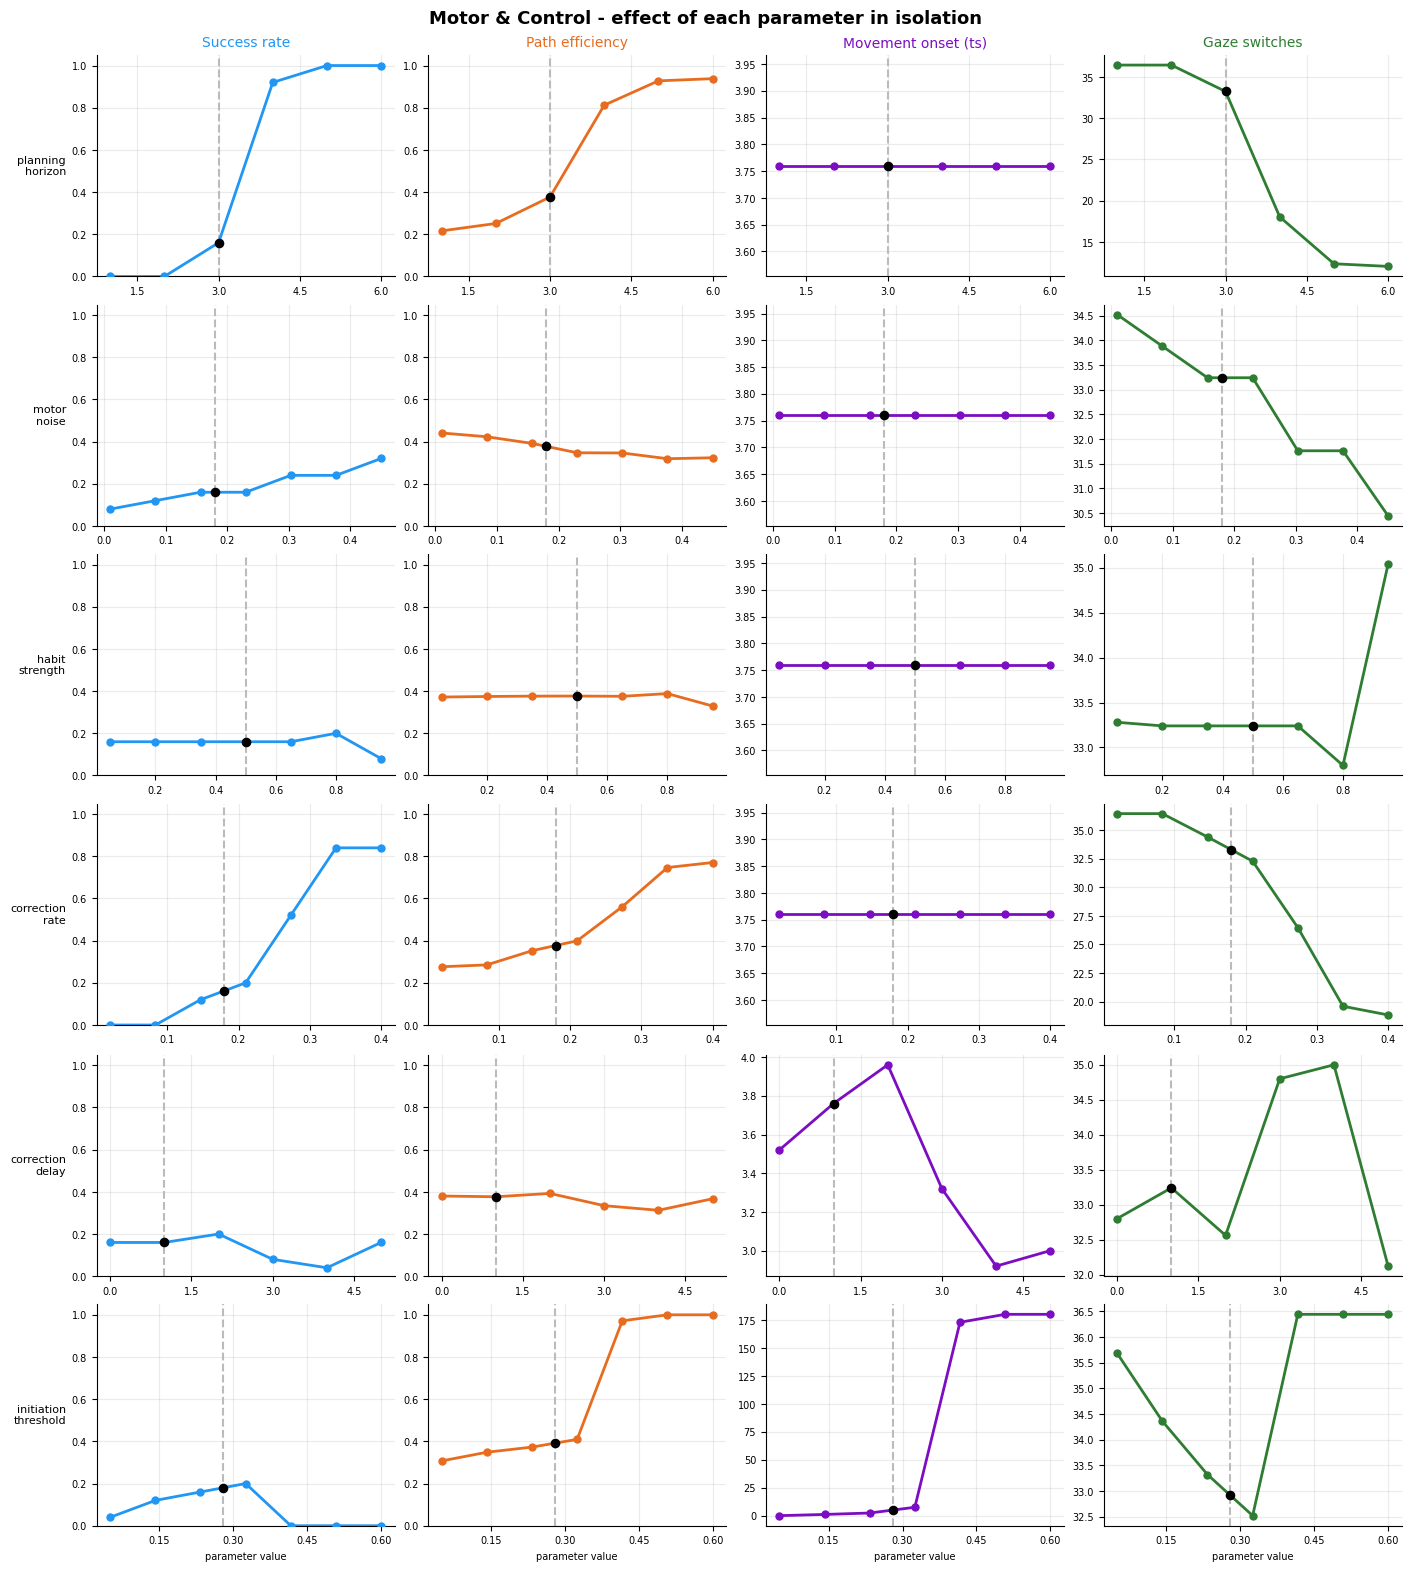

In [11]:
plot_group_sweep("Motor & Control", PARAM_GROUPS["Motor & Control"])

## Most Influential Parameters

The top 6 parameters by mean normalised effect are overlaid
for each metric, making it easy to compare their relative leverage.

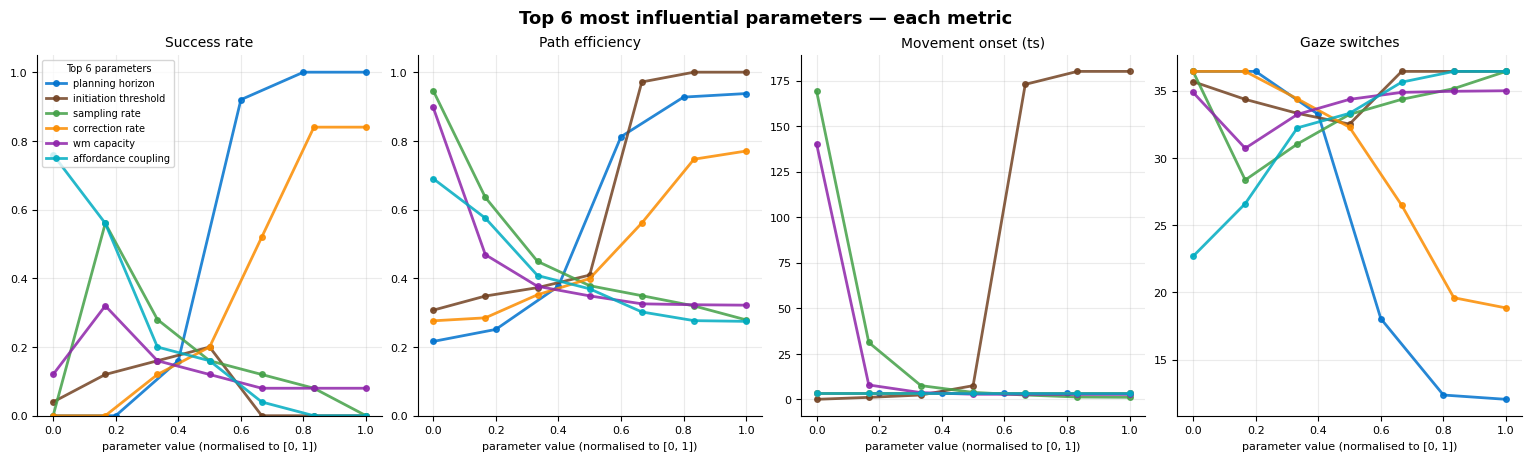

In [12]:
TOP_N = 6
top_params = sorted_params[:TOP_N]

# Distinct palette for top parameters
palette = ["#0072CE", "#734323", "#43A047", "#FB8C00", "#8E24AA", "#00ACC1"]

fig, axes = plt.subplots(1, len(PLOT_METRICS),
                         figsize=(3.8 * len(PLOT_METRICS), 4.5),
                         constrained_layout=True)

for col, (metric, col_title, _, ylim) in enumerate(PLOT_METRICS):
    ax = axes[col]
    for i, param in enumerate(top_params):
        vals = sorted(sweep_data[param])
        y    = [sweep_data[param][v][metric] for v in vals]
        # Normalise x to [0, 1] so parameters with different ranges are comparable
        x_norm = np.linspace(0, 1, len(vals))
        ax.plot(x_norm, y, "o-", lw=2, markersize=4,
                color=palette[i], label=param.replace("_", " "), alpha=0.85)

    ax.set_title(col_title, fontsize=10)
    ax.set_xlabel("parameter value (normalised to [0, 1])", fontsize=8)
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.legend(fontsize=7, title=f"Top {TOP_N} parameters", title_fontsize=7)

fig.suptitle(f"Top {TOP_N} most influential parameters — each metric",
             fontsize=13, fontweight="bold")
plt.show()

## Animate Effect of Each Parameter One at a Time

The top 6 most influential parameters (ranked by the heatmap) are shown
**one parameter at a time**, cycling through them in sequence.

For each parameter, three trials replay simultaneously:

| Column | Value used |
|---|---|
| **Low** | Smallest value in the sweep range |
| **Baseline** | The reference mid-range value |
| **High** | Largest value in the sweep range |

All other parameters stay at `BASELINE`. The same random seed (123) is used
across every trial, so any path difference is caused solely by the one swept
parameter in that segment.

Saved as `param_sweep_animation.mp4`.

In [13]:
TOP_ANIM  = sorted_params[:6]   # top 6 most influential (heatmap order)
LEVELS    = ["Low", "Baseline", "High"]
ANIM_SEED = 123

def anim_values(param):
    """Return (lo, baseline_val, hi) for a parameter."""
    vals = sorted(SWEEP_CONFIG[param])
    return vals[0], getattr(BASELINE, param), vals[-1]

print(f"Running animation trials — 3 values × {len(TOP_ANIM)} parameters on hard task…")
anim_trials = {}
for param in TOP_ANIM:
    lo, base, hi = anim_values(param)
    anim_trials[param] = {}
    for lv, val in zip(LEVELS, [lo, base, hi]):
        kw = {param: val}
        if param == "habit_strength":
            kw["goal_directed_strength"] = round(1.0 - val, 4)
        p = replace(BASELINE, name=f"{param}={val:.3g}", **kw)
        anim_trials[param][lv] = run_trial(p, TASK, seed=ANIM_SEED)

print(f"\nDone — {len(TOP_ANIM) * 3} trials\n")
for param in TOP_ANIM:
    line = "  ".join(
        f"{lv}: {'OK' if anim_trials[param][lv].success else 'FAIL'}"
        f"(t={anim_trials[param][lv].timesteps_used})"
        for lv in LEVELS
    )
    print(f"  {param:<28s}  {line}")

Running animation trials — 3 values × 6 parameters on hard task…

Done — 18 trials

  planning_horizon              Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: OK(t=68)
  initiation_threshold          Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  sampling_rate                 Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  correction_rate               Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: OK(t=84)
  wm_capacity                   Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  affordance_coupling           Low: OK(t=107)  Baseline: FAIL(t=180)  High: FAIL(t=180)


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
from matplotlib.animation import FuncAnimation, FFMpegWriter
import animate_model as am

FPS        = 12
ANIM_STEP  = 3
TRIAL_HOLD = 22

LEVEL_COLOURS = {
    "Low":      "#fb7185",
    "Baseline": "#6ee7b7",
    "High":     "#60a5fa",
}

# Eye position — top-left corner of the workspace
EYE_X, EYE_Y = -0.09, 0.36

# Frame schedule: one segment per parameter 
SCHEDULE = []
for p_idx, param in enumerate(TOP_ANIM):
    max_t = max(len(anim_trials[param][lv].trajectory) for lv in LEVELS)
    for t in list(range(0, max_t, ANIM_STEP)) + [max_t - 1]:
        SCHEDULE.append((p_idx, t, False))
    for _ in range(TRIAL_HOLD):
        SCHEDULE.append((p_idx, max_t - 1, True))

N_FRAMES = len(SCHEDULE)
print(f"{N_FRAMES} frames  (~{N_FRAMES / FPS:.0f}s at {FPS} fps)")

#  Figure: 2 rows × 4 cols; workspace panels span both rows 
fig = plt.figure(figsize=(13, 5.8), dpi=100, facecolor=am.BACKGROUND_COLOUR)
gs  = GridSpec(
    2, 4,
    height_ratios=[3, 2],
    width_ratios=[3, 3, 3, 2.2],
    hspace=0.06, wspace=0.07,
    left=0.02, right=0.99, top=0.87, bottom=0.05,
)
work_axes = [fig.add_subplot(gs[:, c]) for c in range(3)]  # span both rows
succ_ax   = fig.add_subplot(gs[0, 3])
gaze_ax   = fig.add_subplot(gs[1, 3])

param_title = fig.text(
    0.5, 0.975, "",
    ha="center", va="top", fontsize=12, fontweight="bold",
    color=am.ACCENT_COLOUR, fontfamily="serif",
)
fig.text(
    0.5, 0.928,
    f"Task: goal=({TASK.goal_x}, {TASK.goal_y}, {np.degrees(TASK.goal_angle):.0f}°)  "
    f"·  obj {TASK.obj_width:.2f}×{TASK.obj_height:.2f}  "
    f"·  max_t={TASK.max_timesteps}  ·  all other params at BASELINE",
    ha="center", va="top", fontsize=7.5, color=am.DIM_COLOUR,
)
timestep_txt = fig.text(0.5, 0.005, "", ha="center", fontsize=7, color=am.DIM_COLOUR)

# Static workspace setup
_xlim = (-0.15, TASK.goal_x + 0.18)
_ylim = (-TASK.goal_x * 0.52, TASK.goal_x * 0.52)

trails, status_txts, value_txts = {}, {}, {}

for c, lv in enumerate(LEVELS):
    ax     = work_axes[c]
    colour = LEVEL_COLOURS[lv]

    ax.set_facecolor(am.SURFACE_COLOUR)
    ax.set_xlim(*_xlim)
    ax.set_ylim(*_ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(colors=am.DIM_COLOUR, labelsize=5)
    for sp in ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)

    am.draw_rotated_rectangle(
        ax, TASK.goal_x, TASK.goal_y,
        TASK.obj_width + 0.04, TASK.obj_height + 0.04,
        TASK.goal_angle, am.GOAL_COLOUR,
        fc="none", lw=1.5, ls="--", alpha=0.4, z=1,
    )

    ax.set_title(lv, fontsize=11, color=colour, pad=4)

    trail, = ax.plot([], [], color=colour, alpha=0.45, lw=1.3, zorder=2)
    trails[c] = trail

    status_txts[c] = ax.text(
        0.97, 0.05, "", transform=ax.transAxes,
        fontsize=7, ha="right", va="bottom",
        fontfamily="monospace", color=am.TEXT_COLOUR, zorder=15,
    )
    value_txts[c] = ax.text(
        0.03, 0.96, "", transform=ax.transAxes,
        fontsize=7, ha="left", va="top",
        fontfamily="monospace", color=colour, zorder=15,
    )

# Right-column panels: rebuilt whenever the parameter changes
_last_p = [-1]

def _refresh_panels(param):
    vals   = sorted(sweep_data[param])
    y_succ = [sweep_data[param][v]["success_rate"]          for v in vals]
    y_gsw  = np.array([sweep_data[param][v]["mean_gaze_switches"]    for v in vals])
    y_tfix = np.array([sweep_data[param][v]["mean_target_fixation"]  for v in vals])
    y_ofix = np.array([sweep_data[param][v]["mean_object_fixation"]  for v in vals])
    lo, base, hi = anim_values(param)

    # Normalise gaze switches to [0,1] to share the fixation-fraction axis
    gsw_max = float(y_gsw.max()) if y_gsw.max() > 0 else 1.0
    y_gsw_n = y_gsw / gsw_max

    # Success rate panel
    succ_ax.cla()
    succ_ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in succ_ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    succ_ax.plot(vals, y_succ, "-", color=am.DIM_COLOUR, lw=1.5, alpha=0.65)
    succ_ax.fill_between(vals, y_succ, alpha=0.07, color=am.DIM_COLOUR)
    for lv, val in zip(LEVELS, [lo, base, hi]):
        y_pt = float(np.interp(val, vals, y_succ))
        succ_ax.scatter([val], [y_pt], color=LEVEL_COLOURS[lv], s=55, zorder=5,
                        edgecolors=am.BACKGROUND_COLOUR, linewidths=1.5)
    succ_ax.set_ylim(-0.05, 1.10)
    succ_ax.set_title("success rate", fontsize=7, color=am.TEXT_COLOUR, pad=2)
    succ_ax.set_ylabel("rate", fontsize=6, color=am.DIM_COLOUR)
    succ_ax.tick_params(colors=am.DIM_COLOUR, labelsize=5, labelbottom=False)
    succ_ax.grid(alpha=0.18, color=am.BORDER_COLOUR)

    # ── Gaze metrics panel ──
    gaze_ax.cla()
    gaze_ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in gaze_ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    gaze_ax.plot(vals, y_tfix,  "--", color=am.GAZE_COLOUR_TARGET, lw=1.5, alpha=0.85,
                 label="target fix %")
    gaze_ax.plot(vals, y_ofix,  ":",  color="#94a3b8",              lw=1.2, alpha=0.65,
                 label="obj fix %")
    gaze_ax.plot(vals, y_gsw_n, "-",  color=am.GAZE_COLOUR_OBJECT, lw=1.5, alpha=0.85,
                 label=f"switches÷{gsw_max:.0f}")
    for lv, val in zip(LEVELS, [lo, base, hi]):
        gaze_ax.scatter([val], [float(np.interp(val, vals, y_tfix))],
                        color=LEVEL_COLOURS[lv], s=45, zorder=6,
                        marker="^", edgecolors=am.BACKGROUND_COLOUR, linewidths=1.5)
        gaze_ax.scatter([val], [float(np.interp(val, vals, y_gsw_n))],
                        color=LEVEL_COLOURS[lv], s=45, zorder=6,
                        edgecolors=am.BACKGROUND_COLOUR, linewidths=1.5)
    gaze_ax.set_ylim(-0.02, 1.08)
    gaze_ax.set_title("eye gaze", fontsize=7, color=am.TEXT_COLOUR, pad=2)
    gaze_ax.set_xlabel(param.replace("_", " "), fontsize=6, color=am.DIM_COLOUR)
    gaze_ax.set_ylabel("fraction / norm.", fontsize=6, color=am.DIM_COLOUR)
    gaze_ax.tick_params(colors=am.DIM_COLOUR, labelsize=5)
    gaze_ax.grid(alpha=0.18, color=am.BORDER_COLOUR)
    gaze_ax.legend(fontsize=5, loc="best",
                   facecolor=am.SURFACE_COLOUR, edgecolor=am.BORDER_COLOUR,
                   labelcolor=am.TEXT_COLOUR)


# Animation update
def update(frame_idx):
    p_idx, t, is_hold = SCHEDULE[frame_idx]
    param = TOP_ANIM[p_idx]
    lo, base, hi = anim_values(param)

    if p_idx != _last_p[0]:
        _refresh_panels(param)
        _last_p[0] = p_idx
        for c in range(3):
            trails[c].set_data([], [])
            status_txts[c].set_text("")
        for ax in work_axes:
            am.remove_dynamic_artists(ax)

    param_title.set_text(
        f"Parameter: {param.replace('_', ' ')}  ·  [{p_idx + 1} / {len(TOP_ANIM)}]"
    )
    timestep_txt.set_text(f"t = {t}")

    for c, (lv, val) in enumerate(zip(LEVELS, [lo, base, hi])):
        ax     = work_axes[c]
        trial  = anim_trials[param][lv]
        traj   = trial.trajectory
        t_c    = min(t, len(traj) - 1)
        step   = traj[t_c]
        colour = LEVEL_COLOURS[lv]

        am.remove_dynamic_artists(ax)

        trails[c].set_data(
            [s.obj_x for s in traj[:t_c + 1]],
            [s.obj_y for s in traj[:t_c + 1]],
        )

        am.mark_dynamic(am.draw_rotated_rectangle(
            ax, step.obj_x, step.obj_y,
            TASK.obj_width, TASK.obj_height,
            step.obj_angle, colour, alpha=0.88,
        ))

        # ── Gaze: eye circle + fixation target + connecting line ──
        looking_at_object = step.gaze_target == "object"
        gz_col = am.GAZE_COLOUR_OBJECT if looking_at_object else am.GAZE_COLOUR_TARGET
        fix_x  = step.obj_x if looking_at_object else TASK.goal_x
        fix_y  = step.obj_y if looking_at_object else TASK.goal_y

        for circle in (
            mpatches.Circle((EYE_X, EYE_Y), 0.028, fc=gz_col,
                             ec="none", alpha=0.85, zorder=10),
            mpatches.Circle((EYE_X, EYE_Y), 0.012, fc=am.BACKGROUND_COLOUR,
                             ec="none", alpha=0.90, zorder=11),
            mpatches.Circle((fix_x, fix_y),  0.022, fc=gz_col,
                             ec="white", lw=0.4, alpha=0.70, zorder=8),
        ):
            ax.add_patch(am.mark_dynamic(circle))

        gz_line, = ax.plot(
            [EYE_X, fix_x], [EYE_Y, fix_y],
            color=gz_col, lw=0.9, alpha=0.40, zorder=5,
        )
        am.mark_dynamic(gz_line)
        am.mark_dynamic(ax.text(
            EYE_X + 0.055, EYE_Y, "obj" if looking_at_object else "tgt",
            fontsize=5, color=gz_col, va="center",
            fontfamily="monospace", alpha=0.85, zorder=12,
        ))

        value_txts[c].set_text(f"= {val:.3g}")

        done = (t >= len(traj) - 1)
        if done:
            status_txts[c].set_text("SUCCESS" if trial.success else "FAIL")
            status_txts[c].set_color(am.ACCENT_COLOUR if trial.success else "#fb7185")
        else:
            status_txts[c].set_text(f"err={step.pos_error:.2f}")
            status_txts[c].set_color(am.DIM_COLOUR)

    return []

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=1000 / FPS, blit=False)
plt.close()
print(f"Animation built: {N_FRAMES} frames at {FPS} fps  (~{N_FRAMES / FPS:.0f}s)")

498 frames  (~42s at 12 fps)
Animation built: 498 frames at 12 fps  (~42s)


In [17]:
_base    = cwd if (cwd / "planning_cascade_model.py").exists() else cwd / "gaze_model"
mp4_path = _base / "param_sweep_animation.mp4"

writer = FFMpegWriter(
    fps=FPS, bitrate=2000, codec="h264",
    extra_args=["-pix_fmt", "yuv420p"],   # broad player compatibility
)
anim.save(
    str(mp4_path), writer=writer, dpi=100,
    savefig_kwargs={"facecolor": am.BACKGROUND_COLOUR},
)
print(f"Saved: {mp4_path}")
print(f"File size: {mp4_path.stat().st_size / 1_000_000:.1f} MB")

Saved: /Users/katiesavva/action-planning/gaze_model/param_sweep_animation.mp4
File size: 1.4 MB


## Gaze Impact per Parameter

For each of the top-6 most influential parameters, three gaze metrics are plotted
across the full sweep range (all other params fixed at `BASELINE`):

| Colour | Line style | Metric | Axis |
|---|---|---|---|
| Violet | `--` dashed | Target fixation % | Left (0–1 fraction) |
| Grey | `:` dotted | Object fixation % | Left (0–1 fraction) |
| Amber | `—` solid | Gaze switches | Right (raw count) |

Triangular markers (▲) track fixation values and circular markers (●) track gaze
switches at the **Low / Baseline / High** levels used in the animation above.
The vertical dashed line marks the baseline parameter value.

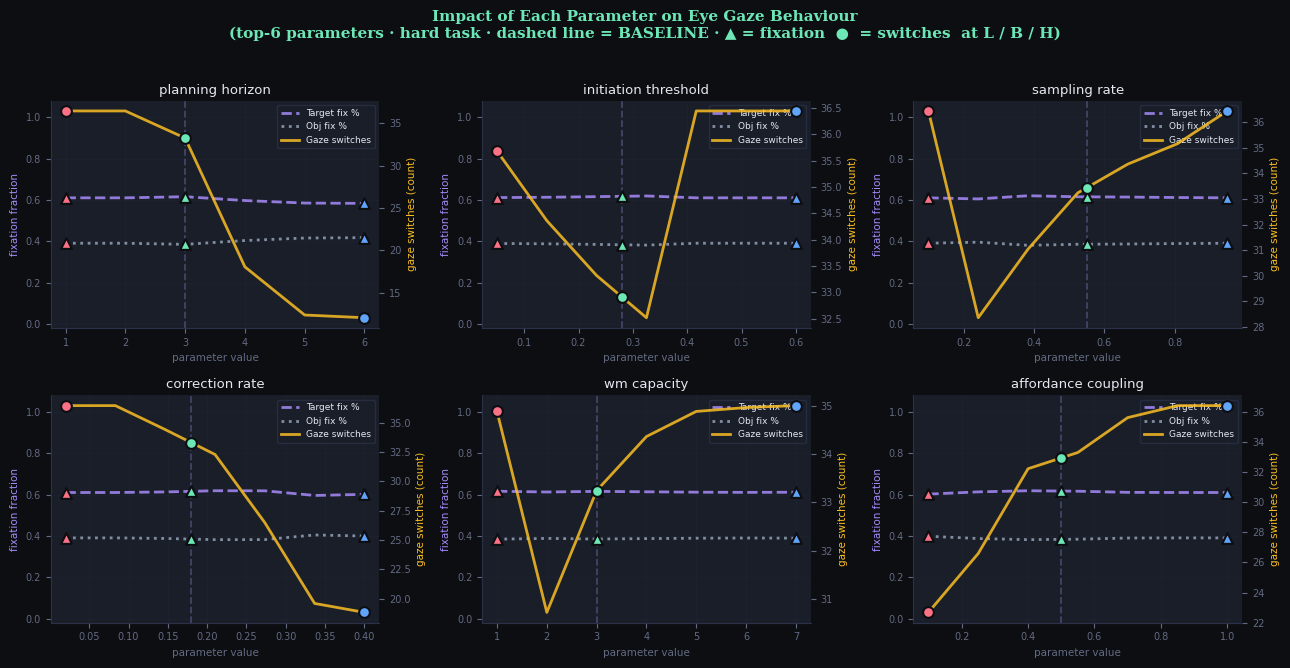

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import animate_model as am

# Left axis: target and object fixation fractions (0–1)
_FIX_METRICS = [
    ("mean_target_fixation", "Target fix %", am.GAZE_COLOUR_TARGET, "--"),
    ("mean_object_fixation", "Obj fix %",    "#94a3b8",              ":"),
]
# Right axis: raw gaze-switch count
_SW_METRIC = ("mean_gaze_switches", "Gaze switches", am.GAZE_COLOUR_OBJECT, "-")

fig, all_axes = plt.subplots(
    2, 3, figsize=(13, 6.5), facecolor=am.BACKGROUND_COLOUR,
)
fig.patch.set_facecolor(am.BACKGROUND_COLOUR)

for idx, param in enumerate(TOP_ANIM):
    ax  = all_axes.flat[idx]
    ax2 = ax.twinx()

    ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    for sp in ax2.spines.values():
        sp.set_color(am.BORDER_COLOUR)

    vals  = sorted(sweep_data[param])
    b_val = getattr(BASELINE, param)
    lo, base, hi = anim_values(param)

    # Left axis — fixation fractions
    for metric, label, colour, ls in _FIX_METRICS:
        y = [sweep_data[param][v][metric] for v in vals]
        ax.plot(vals, y, ls=ls, color=colour, lw=2.0, alpha=0.85, label=label)
        for lv, val in zip(LEVELS, [lo, base, hi]):
            ax.scatter([val], [float(np.interp(val, vals, y))],
                       color=LEVEL_COLOURS[lv], s=60, zorder=6,
                       marker="^", edgecolors=am.BACKGROUND_COLOUR, linewidths=1.5)

    # Right axis — gaze switches
    metric_sw, label_sw, colour_sw, ls_sw = _SW_METRIC
    y_sw = [sweep_data[param][v][metric_sw] for v in vals]
    ax2.plot(vals, y_sw, ls=ls_sw, color=colour_sw, lw=2.0, alpha=0.85, label=label_sw)
    for lv, val in zip(LEVELS, [lo, base, hi]):
        ax2.scatter([val], [float(np.interp(val, vals, y_sw))],
                    color=LEVEL_COLOURS[lv], s=60, zorder=6,
                    edgecolors=am.BACKGROUND_COLOUR, linewidths=1.5)

    ax.axvline(b_val, color="#444466", lw=1.3, ls="--", zorder=2)

    ax.set_ylim(-0.02, 1.08)
    ax.set_title(param.replace("_", " "), fontsize=9.5, color=am.TEXT_COLOUR, pad=5)
    ax.set_xlabel("parameter value",         fontsize=7.5, color=am.DIM_COLOUR)
    ax.set_ylabel("fixation fraction",        fontsize=7.5, color=am.GAZE_COLOUR_TARGET)
    ax2.set_ylabel("gaze switches (count)",   fontsize=7.5, color=am.GAZE_COLOUR_OBJECT)
    ax.tick_params(colors=am.DIM_COLOUR,  labelsize=7)
    ax2.tick_params(colors=am.DIM_COLOUR, labelsize=7)
    ax.grid(alpha=0.18, color=am.BORDER_COLOUR)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2,
              fontsize=6.5, loc="best",
              facecolor=am.SURFACE_COLOUR, edgecolor=am.BORDER_COLOUR,
              labelcolor=am.TEXT_COLOUR)

fig.suptitle(
    "Impact of Each Parameter on Eye Gaze Behaviour\n"
    f"(top-{len(TOP_ANIM)} parameters · hard task · dashed line = BASELINE · "
    "▲ = fixation  ●  = switches  at L / B / H)",
    fontsize=11, fontweight="bold", color=am.ACCENT_COLOUR,
    fontfamily="serif", y=1.02,
)
plt.tight_layout()
plt.show()